<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana7/Semana7_Dia2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DIA 1: O REGRESSOR ESPACIAL (PASCAL VOC vs YOLO)


array([[[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       ...,

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]]], dtype=uint8)
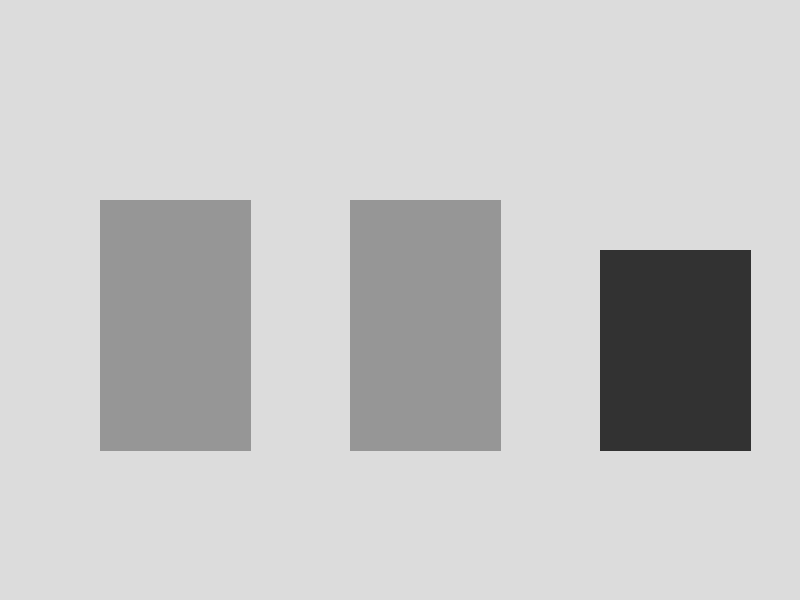

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("="*75)
print("DIA 1: O REGRESSOR ESPACIAL (PASCAL VOC vs YOLO)")
print("="*75)

# ==============================================================================
# 1. AMBIENTE DE SIMULAÇÃO (Câmera Industrial de Alta Velocidade)
# ==============================================================================
# Tela de 600x800 simulando a esteira
frame_esteira = np.ones((600, 800, 3), dtype=np.uint8) * 220

# Desenhando três "frascos" na esteira
cv2.rectangle(frame_esteira, (100, 200), (250, 450), (150, 150, 150), -1) # OK
cv2.rectangle(frame_esteira, (350, 200), (500, 450), (150, 150, 150), -1) # OK
cv2.rectangle(frame_esteira, (600, 250), (750, 450), (50, 50, 50), -1)    # Defeito (Falta a tampa no topo)

array([[[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       ...,

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]]], dtype=uint8)
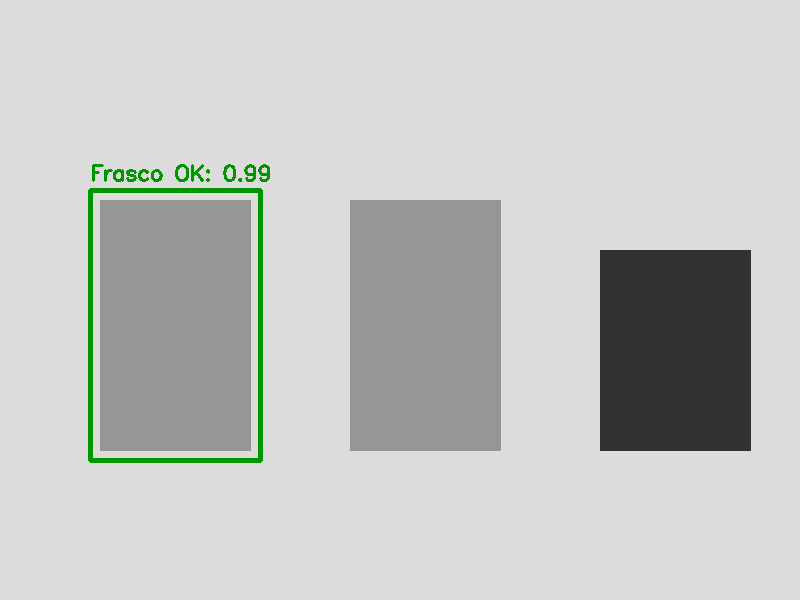

In [ ]:
# ==============================================================================
# 2. O PADRÃO PASCAL VOC (Coordenadas Absolutas)
# ==============================================================================
# A IA aponta: [X_min, Y_min, X_max, Y_max]
tensor_voc = [90, 190, 260, 460]
confianca_voc = 0.99

imagem_voc = frame_esteira.copy()
cv2.rectangle(imagem_voc, (tensor_voc[0], tensor_voc[1]), (tensor_voc[2], tensor_voc[3]), (0, 150, 0), 4)
cv2.putText(imagem_voc, f"Frasco OK: {confianca_voc:.2f}", (tensor_voc[0], tensor_voc[1] - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 150, 0), 2)

array([[[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       ...,

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]],

       [[220, 220, 220],
        [220, 220, 220],
        [220, 220, 220],
        ...,
        [220, 220, 220],
        [220, 220, 220],
        [220, 220, 220]]], dtype=uint8)
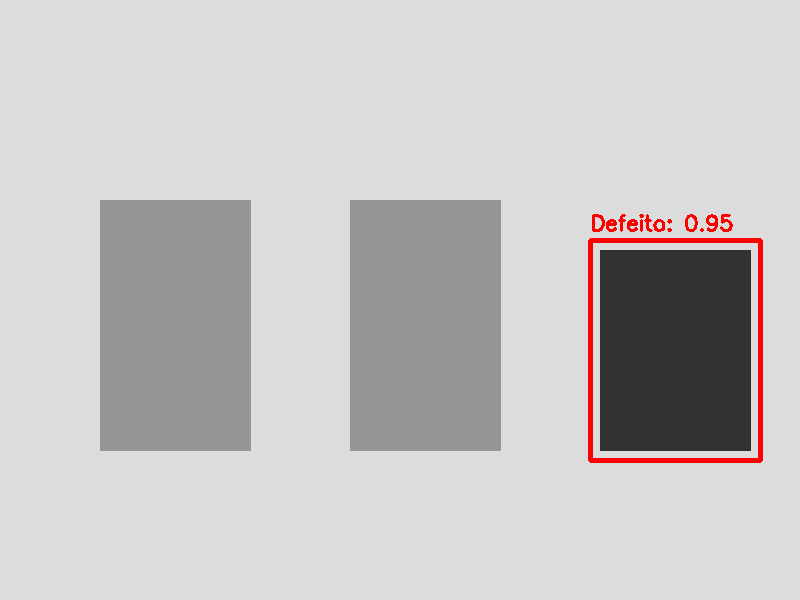

In [ ]:
# ==============================================================================
# 3. O PADRÃO YOLO (Centro de Gravidade e Expansão)
# ==============================================================================
# A IA aponta: [X_centro, Y_centro, Largura, Altura]
tensor_yolo = [675, 350, 170, 220]
confianca_yolo = 0.95

imagem_yolo = frame_esteira.copy()

# Conversão: OpenCV não entende YOLO, precisamos voltar para coordenadas de quinas
x_centro, y_centro, w, h = tensor_yolo
x_min = int(x_centro - (w / 2))
y_min = int(y_centro - (h / 2))
x_max = int(x_centro + (w / 2))
y_max = int(y_centro + (h / 2))

cv2.rectangle(imagem_yolo, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
cv2.putText(imagem_yolo, f"Defeito: {confianca_yolo:.2f}", (x_min, y_min - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

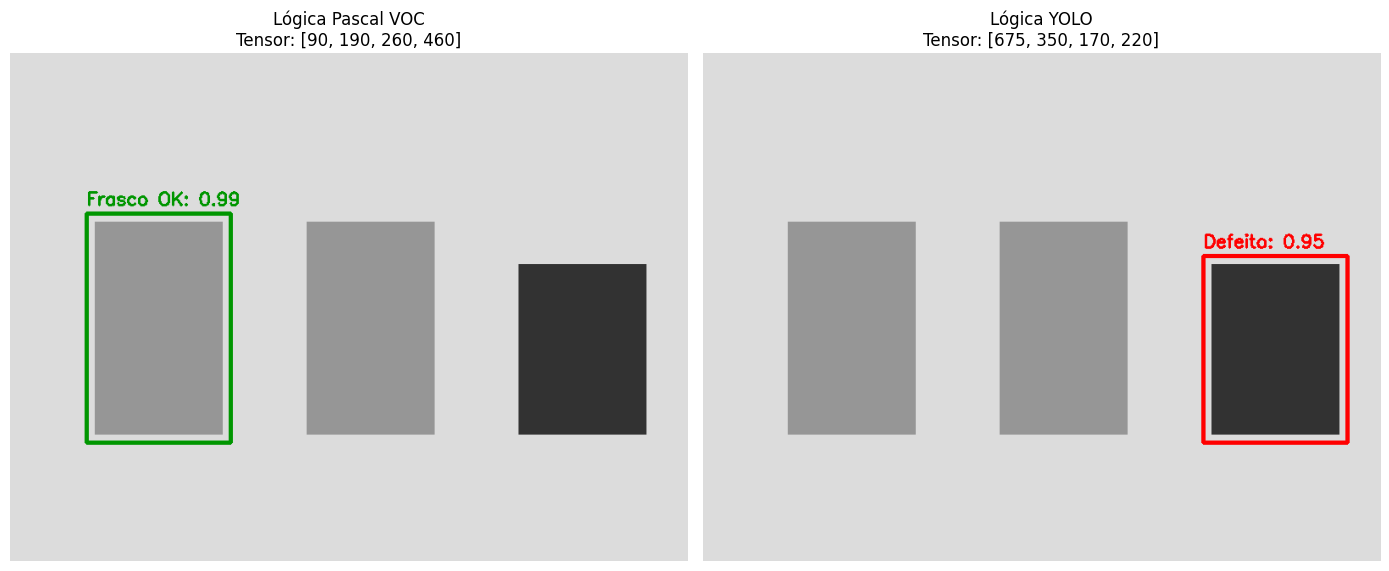


[INSIGHT DA AULA]: A rede neural não manipula pixels na saída.
Ela manipula apenas esses 4 valores por objeto, o que a torna incrivelmente leve.


In [ ]:
# ==============================================================================
# 4. EXIBIÇÃO DIDÁTICA
# ==============================================================================
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(imagem_voc)
plt.title(f"Lógica Pascal VOC\nTensor: {tensor_voc}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imagem_yolo)
plt.title(f"Lógica YOLO\nTensor: {tensor_yolo}")
plt.axis('off')

plt.tight_layout()
plt.show()

print("\n[INSIGHT DA AULA]: A rede neural não manipula pixels na saída.")
print("Ela manipula apenas esses 4 valores por objeto, o que a torna incrivelmente leve.")